In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import copy
import time
from PIL import Image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

# ── Data Pipeline Configuration ──
# ImageNet statistics for standardization: μ=[0.485, 0.456, 0.406], σ=[0.229, 0.224, 0.225]
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# Note: num_workers=0 used for Windows compatibility; increase for Linux/MacOS environments
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes


Compute Device: cuda:0


In [3]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    """
    Executes standard PyTorch training loop with validation evaluation.
    Tracks and restores the state_dict corresponding to the highest validation accuracy.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}', end=' | ')

        for phase in ['train', 'val']:
            if phase == 'train': model.train()  
            else: model.eval()   

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                # Context-manager that enables gradient calculation only during training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train': scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Acc: {epoch_acc:.4f}', end=' ')

            # Checkpoint the optimal model weights
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    print(f'\nBest val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

# ── Architecture Setup: ResNet18 ──
model = models.resnet18(weights='IMAGENET1K_V1')

# Feature Extraction Paradigm: Freeze all convolutional base parameters
for param in model.parameters():
    param.requires_grad = False  

# Reinitialize the classification head for the target domain (2 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Optimize ONLY the parameters of the newly initialized FC layer
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

# StepLR: Decays learning rate by gamma every step_size epochs
step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Execute training and serialize the state_dict
print("Initiating training...")
model = train_model(model, criterion, optimizer, step_lr_scheduler, num_epochs=10)

torch.save(model.state_dict(), 'ant_bee_model_clean.pth')
print("Model serialized to: ant_bee_model_clean.pth")


Initiating training...
Epoch 0/9 | train Acc: 0.6680 val Acc: 0.9150 
Epoch 1/9 | train Acc: 0.7828 val Acc: 0.9281 
Epoch 2/9 | train Acc: 0.7541 val Acc: 0.9346 
Epoch 3/9 | train Acc: 0.8484 val Acc: 0.8954 
Epoch 4/9 | train Acc: 0.8074 val Acc: 0.9216 
Epoch 5/9 | train Acc: 0.7787 val Acc: 0.9477 
Epoch 6/9 | train Acc: 0.8115 val Acc: 0.8627 
Epoch 7/9 | train Acc: 0.8115 val Acc: 0.9412 
Epoch 8/9 | train Acc: 0.8484 val Acc: 0.9477 
Epoch 9/9 | train Acc: 0.8648 val Acc: 0.9542 

Best val Acc: 0.954248
Model serialized to: ant_bee_model_clean.pth


Detected 8 dead filters in the pretrained IMAGENET1K_V1 distribution.


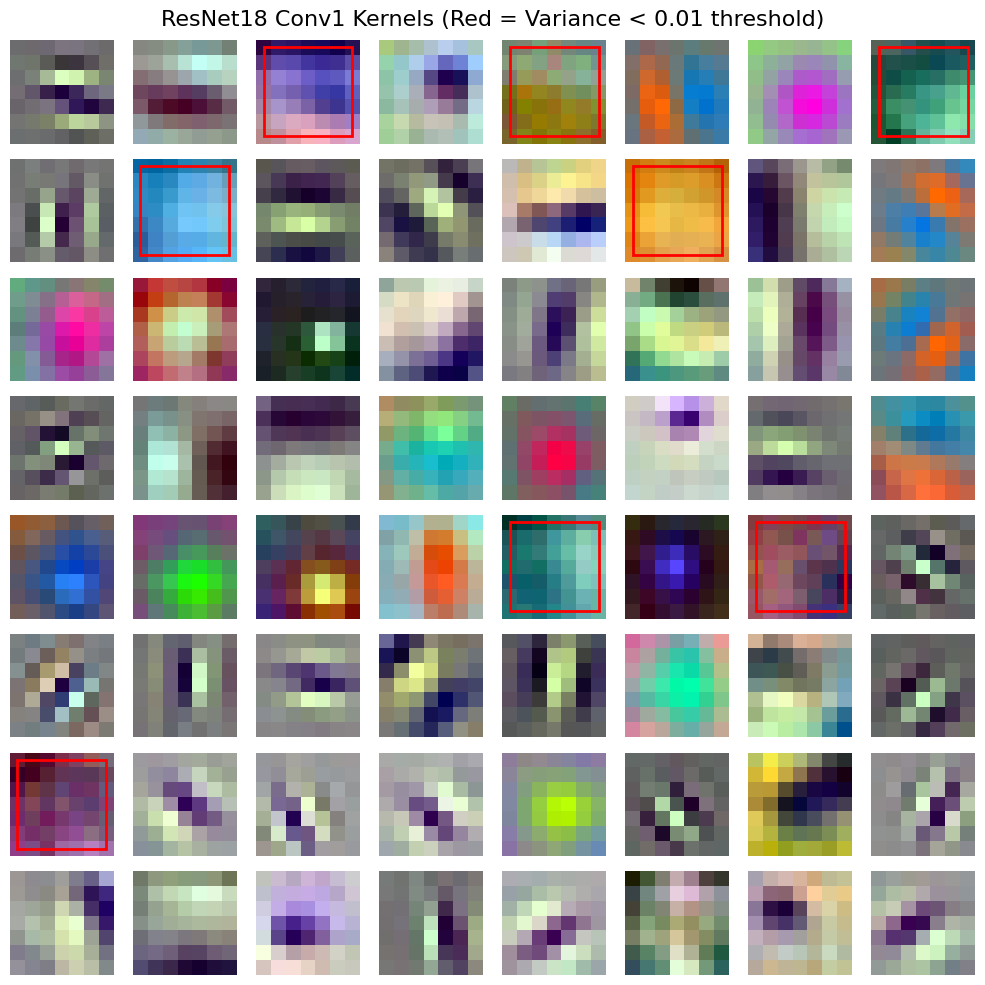

In [4]:
# ─────────────────────────────────────────────────────────────────
# XAI PHASE 1 & 2: First-Layer Filter Analysis & Dead Node Detection
# ─────────────────────────────────────────────────────────────────
# Retrieve weights from the initial convolution: shape [out_channels, in_channels, kernel_h, kernel_w]
conv1_weights = model.conv1.weight.detach().cpu()

# Calculate variance across spatial and channel dimensions to identify "dead" filters
# Heuristic threshold: std < 0.01 typically indicates a collapsed/unoptimized filter
filter_stds = conv1_weights.std(dim=[1, 2, 3])
dead_filters = (filter_stds < 0.01).nonzero(as_tuple=True)[0]
print(f"Detected {len(dead_filters)} dead filters in the pretrained IMAGENET1K_V1 distribution.")

# Visualization: First 64 spatial filters (7x7 kernels)
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle("ResNet18 Conv1 Kernels (Red = Variance < 0.01 threshold)", fontsize=16)

for i, ax in enumerate(axes.flat):
    # Min-Max normalization for visual rendering [0, 255] equivalent
    f = conv1_weights[i]
    f_min, f_max = f.min(), f.max()
    f_norm = (f - f_min) / (f_max - f_min + 1e-8)
    
    # Transpose dimensions from PyTorch [C, H, W] to Matplotlib [H, W, C]
    f_img = f_norm.permute(1, 2, 0).numpy()
    
    ax.imshow(f_img)
    ax.axis('off')
    
    # Annotate inactive filters
    if i in dead_filters:
        rect = plt.Rectangle((0, 0), 6, 6, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)

plt.tight_layout()
plt.show()


Identified 7 misclassifications. Visualizing top 3 via Grad-CAM...


C:\Users\Uttam Parmar\AppData\Local\Temp\ipykernel_24456\746519320.py:113: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Uttam\Project\Own_Project\Deep Learning\001\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


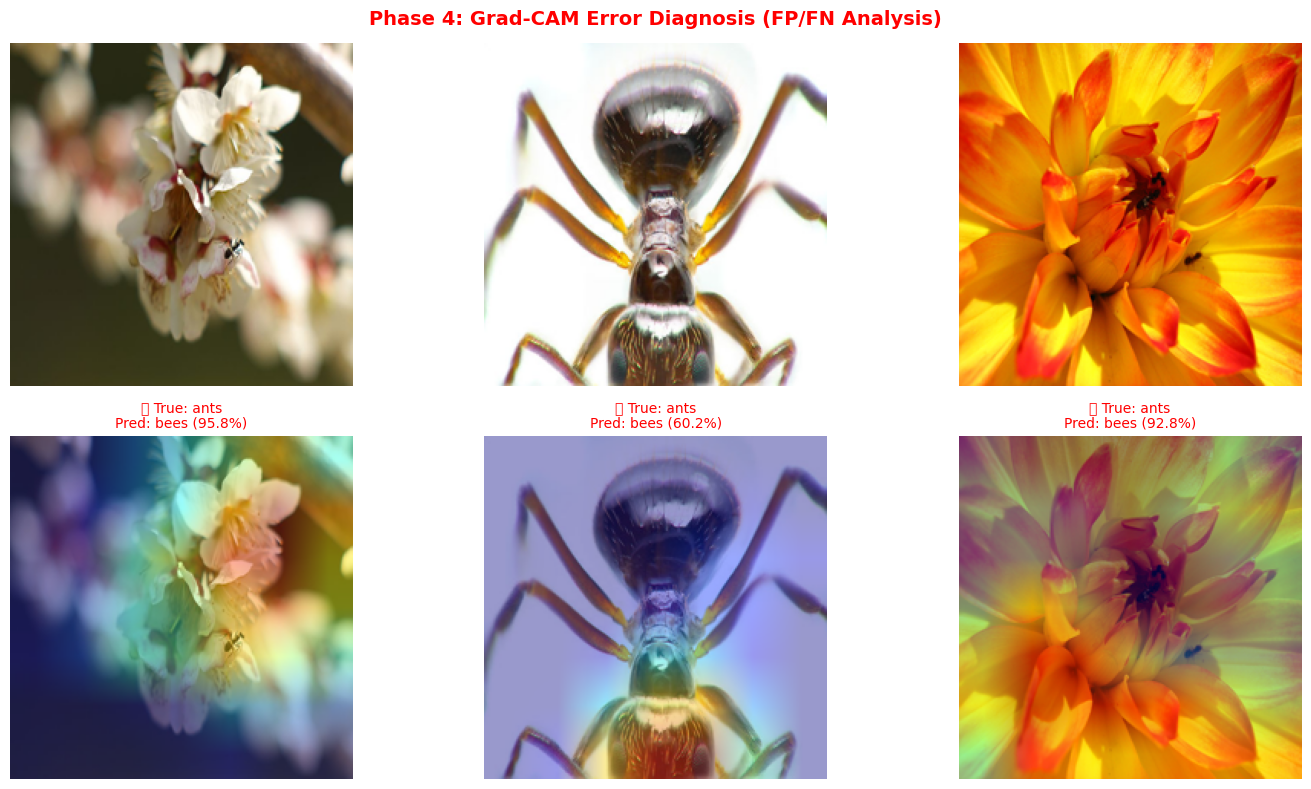

In [6]:
# ─────────────────────────────────────────────────────────────────
# XAI PHASE 3 & 4: Gradient-Weighted Class Activation Mapping (Grad-CAM)
# ─────────────────────────────────────────────────────────────────
model.eval()
model.cpu() 

grad_store = {}
act_store  = {}

def save_grad(name):
    """Closure for registering backward hooks to capture gradients wrt feature maps."""
    def hook(grad): grad_store[name] = grad.detach().cpu()
    return hook

def save_act(name):
    """Closure for registering forward hooks to capture spatial activations."""
    def hook(module, input, output):
        act_store[name] = output.detach().cpu()
        output.register_hook(save_grad(name))
    return hook

# Target the deepest convolutional layer prior to global average pooling (GAP)
model.layer4.register_forward_hook(save_act('layer4'))

def run_gradcam(image_path, label):
    """
    Computes the Grad-CAM heatmap:
    H^c = ReLU( Σ (α^c_k * A^k) ) where α^c_k = GAP(∂y^c / ∂A^k)
    """
    img = Image.open(image_path).convert('RGB')
    x = data_transforms['val'](img).unsqueeze(0)
    x.requires_grad = True

    out = model(x)
    probs = torch.softmax(out, dim=1)
    pred_idx = out.argmax().item()
    confidence = probs.max().item() * 100

    # Backpropagate from the predicted class logit to compute ∂y^c / ∂A^k
    model.zero_grad()
    out[0][pred_idx].backward()

    A = act_store['layer4'][0]              # Spatial activations A^k [512, 7, 7]
    G = grad_store['layer4'][0]             # Gradients ∂y^c / ∂A^k [512, 7, 7]
    
    # Compute neuron importance weights α^c_k via Global Average Pooling
    alpha = G.mean(dim=[1, 2])              # [512]
    
    # Linear combination of feature maps weighted by alpha
    heatmap = (alpha[:, None, None] * A).sum(dim=0)
    
    # Apply ReLU to retain only positive influences on the class prediction
    heatmap = torch.clamp(heatmap, min=0)
    
    # L-Infinity Normalization
    max_val = heatmap.max()
    if max_val > 0: heatmap /= max_val
        
    # Upsampling & Overlay via OpenCV
    heatmap_np = heatmap.numpy()
    h_uint8 = np.uint8(255 * heatmap_np)
    h_color = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
    h_color = cv2.resize(h_color, (224, 224))
    h_color = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    
    orig_np = np.array(img.resize((224, 224))).astype(np.float32)
    overlay = (0.4 * h_color + 0.6 * orig_np).astype(np.uint8)

    correct = "✅" if class_names[pred_idx] == label else "❌"
    title = f'{correct} True: {label}\nPred: {class_names[pred_idx]} ({confidence:.1f}%)'
    return overlay, title

# ── Validation Set Error Analysis ──
val_dir = os.path.join(data_dir, 'val')
misclassified = []

# Scan for FP/FN occurrences
for class_idx, class_name in enumerate(class_names):
    folder = os.path.join(val_dir, class_name)
    for img_name in os.listdir(folder):
        if not img_name.endswith('.jpg'): continue
        path = os.path.join(folder, img_name)
        img = Image.open(path).convert('RGB')
        x = data_transforms['val'](img).unsqueeze(0)
        x.requires_grad = True
        
        # Forward pass (requires_grad maintained for backward hook compatibility)
        pred_idx = model(x).argmax().item()
        if pred_idx != class_idx:
            misclassified.append((path, class_name))

print(f"Identified {len(misclassified)} misclassifications. Visualizing top 3 via Grad-CAM...")

# Render Error Diagnostics
num_show = min(3, len(misclassified))
if num_show > 0:
    fig, axes = plt.subplots(2, num_show, figsize=(5 * num_show, 8))
    fig.suptitle('Phase 4: Grad-CAM Error Diagnosis (FP/FN Analysis)', fontsize=14, color='red', fontweight='bold')

    for col in range(num_show):
        path, true_label = misclassified[col]
        overlay, title = run_gradcam(path, true_label)
        
        ax_top = axes[0, col] if num_show > 1 else axes[0]
        ax_bot = axes[1, col] if num_show > 1 else axes[1]
        
        ax_top.imshow(Image.open(path).resize((224, 224)))
        ax_top.axis('off')
        ax_bot.imshow(overlay)
        ax_bot.set_title(title, fontsize=10, color='red')
        ax_bot.axis('off')

    plt.tight_layout()
    plt.show()


In [7]:
# ─────────────────────────────────────────────────────────────────
# PHASE 5: Custom CNN Comparison (Training from Scratch)
# ─────────────────────────────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        # Block 1: 3 channels (RGB) -> 16 feature maps
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Block 2: 16 -> 32 feature maps
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Block 3: 32 -> 64 feature maps
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Classifier
        # After 3 MaxPools, 224x224 image becomes 28x28
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, len(class_names))

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize our custom model
custom_model = CustomCNN().to(device)

criterion = nn.CrossEntropyLoss()
# Notice we optimize ALL parameters here, not just the fc layer!
optimizer_custom = optim.SGD(custom_model.parameters(), lr=0.001, momentum=0.9)
scheduler_custom = lr_scheduler.StepLR(optimizer_custom, step_size=7, gamma=0.1)

print("Starting training for Custom CNN from scratch...")
custom_model = train_model(custom_model, criterion, optimizer_custom, scheduler_custom, num_epochs=15)

torch.save(custom_model.state_dict(), 'custom_cnn_model.pth')
print("Custom CNN saved to: custom_cnn_model.pth")


Starting training for Custom CNN from scratch...
Epoch 0/14 | train Acc: 0.4959 val Acc: 0.4510 
Epoch 1/14 | train Acc: 0.5410 val Acc: 0.5752 
Epoch 2/14 | train Acc: 0.5615 val Acc: 0.5948 
Epoch 3/14 | train Acc: 0.5984 val Acc: 0.5359 
Epoch 4/14 | train Acc: 0.6066 val Acc: 0.6078 
Epoch 5/14 | train Acc: 0.6066 val Acc: 0.5490 
Epoch 6/14 | train Acc: 0.6066 val Acc: 0.5098 
Epoch 7/14 | train Acc: 0.5902 val Acc: 0.5490 
Epoch 8/14 | train Acc: 0.6270 val Acc: 0.5359 
Epoch 9/14 | train Acc: 0.6311 val Acc: 0.5490 
Epoch 10/14 | train Acc: 0.6270 val Acc: 0.5425 
Epoch 11/14 | train Acc: 0.6066 val Acc: 0.5359 
Epoch 12/14 | train Acc: 0.6516 val Acc: 0.5686 
Epoch 13/14 | train Acc: 0.6311 val Acc: 0.5686 
Epoch 14/14 | train Acc: 0.6148 val Acc: 0.5686 

Best val Acc: 0.607843
Custom CNN saved to: custom_cnn_model.pth


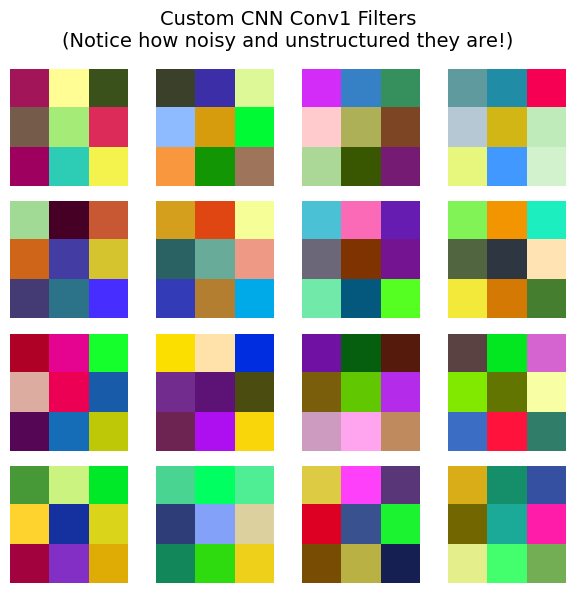

In [8]:
# ─────────────────────────────────────────────────────────────────
# PHASE 5: Visualizing Custom CNN's "Confused" Filters
# ─────────────────────────────────────────────────────────────────
# Get the 16 filters from the first convolutional layer
custom_weights = custom_model.conv1.weight.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle("Custom CNN Conv1 Filters\n(Notice how noisy and unstructured they are!)", fontsize=14)

for i, ax in enumerate(axes.flat):
    f = custom_weights[i]
    f_min, f_max = f.min(), f.max()
    f_norm = (f - f_min) / (f_max - f_min + 1e-8)
    
    # PyTorch is [C, H, W] -> matplotlib [H, W, C]
    f_img = f_norm.permute(1, 2, 0).numpy()
    
    ax.imshow(f_img)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [9]:
# ─────────────────────────────────────────────────────────────────
# PHASE 5: ResNet18 From Scratch (The Ultimate Comparison)
# ─────────────────────────────────────────────────────────────────
# By setting weights=None, we get the EXACT ResNet18 architecture, 
# but with completely random, untrained weights.
resnet_from_scratch = models.resnet18(weights=None)

# Adjust the final layer for our 2 classes (ants/bees)
num_ftrs = resnet_from_scratch.fc.in_features
resnet_from_scratch.fc = nn.Linear(num_ftrs, len(class_names))
resnet_from_scratch = resnet_from_scratch.to(device)

criterion = nn.CrossEntropyLoss()

# IMPORTANT: We optimize ALL parameters because none of them are pre-trained!
optimizer_scratch = optim.SGD(resnet_from_scratch.parameters(), lr=0.001, momentum=0.9)
scheduler_scratch = lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

print("Starting training for ResNet18 FROM SCRATCH (No Transfer Learning)...")
resnet_from_scratch = train_model(resnet_from_scratch, criterion, optimizer_scratch, scheduler_scratch, num_epochs=15)


Starting training for ResNet18 FROM SCRATCH (No Transfer Learning)...
Epoch 0/14 | train Acc: 0.5820 val Acc: 0.5229 
Epoch 1/14 | train Acc: 0.5574 val Acc: 0.5621 
Epoch 2/14 | train Acc: 0.5861 val Acc: 0.5098 
Epoch 3/14 | train Acc: 0.5820 val Acc: 0.4706 
Epoch 4/14 | train Acc: 0.5984 val Acc: 0.6667 
Epoch 5/14 | train Acc: 0.5574 val Acc: 0.6275 
Epoch 6/14 | train Acc: 0.6148 val Acc: 0.6340 
Epoch 7/14 | train Acc: 0.6680 val Acc: 0.6405 
Epoch 8/14 | train Acc: 0.6803 val Acc: 0.6732 
Epoch 9/14 | train Acc: 0.6926 val Acc: 0.6797 
Epoch 10/14 | train Acc: 0.6803 val Acc: 0.6667 
Epoch 11/14 | train Acc: 0.6393 val Acc: 0.6732 
Epoch 12/14 | train Acc: 0.6516 val Acc: 0.6601 
Epoch 13/14 | train Acc: 0.6926 val Acc: 0.6993 
Epoch 14/14 | train Acc: 0.6311 val Acc: 0.7124 

Best val Acc: 0.712418
